# Usage examples

This notebook shows practical examples for working with the data from A multiresolution weather dataset for the Southwestern South Atlantic (2017-2018) using Python. NetCDF files are open using the xarray library.

- Calculating **wind speed** from wind components
- Retrieving **wind components at different heights**
- Selecting the **nearest grid-point value**
- Saving data to **csv file**
- Useful **plots**

## Libraries

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Data loading

In [2]:
# wrf
data_20170206_D01 = xr.open_dataset('/total/dataset_total/dados/D01/2017/data_D01_20170206.nc')
data_20170206_D02 = xr.open_dataset('/total/dataset_total/dados/D02/2017/data_D02_20170206.nc')
data_20170206_D03 = xr.open_dataset('/total/dataset_total/dados/D03/2017/data_D03_20170206.nc')

# wrf_air_density
air_density_D01 = xr.open_dataset('/total/dataset_total/rho_outputs/air_density_d01_2017_2018_stats.nc')
air_density_D02 = xr.open_dataset('/total/dataset_total/rho_outputs/air_density_d02_2017_2018_stats.nc')
air_density_D03 = xr.open_dataset('/total/dataset_total/rho_outputs/air_density_d03_2017_2018_stats.nc')

# SAR
SAR_1000m = xr.open_dataset('../data_description_article/0_data/d0sar/data_SAR_1000m.nc')

## WRF Data exploration

### Data for February 6, 2018, D01 grid

In [3]:
data_20170206_D01

<xarray.Dataset>
Dimensions:   (Time: 35, south_north: 354, west_east: 360, bottom_top: 4,
               bottom_top_stag: 5, west_east_stag: 361, south_north_stag: 355)
Coordinates:
    XLAT      (south_north, west_east) float32 ...
    XLONG     (south_north, west_east) float32 ...
    Times     (Time) object ...
    XLAT_U    (south_north, west_east_stag) float32 ...
    XLONG_U   (south_north, west_east_stag) float32 ...
    XLAT_V    (south_north_stag, west_east) float32 ...
    XLONG_V   (south_north_stag, west_east) float32 ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, west_east_stag,
                                south_north_stag
Data variables: (12/21)
    T2        (Time, south_north, west_east) float32 ...
    TH2       (Time, south_north, west_east) float32 ...
    SST       (Time, south_north, west_east) float32 ...
    PSFC      (Time, south_north, west_east) float32 ...
    RAINC     (Time, south_north, west_east) float32 ...
    RAINNC    (Time, south_north, west_east) float32 ...
    ...        ...
    P         (Time, bottom_top, south_north, west_east) float32 ...
    PH        (Time, bottom_top_stag, south_north, west_east) float32 ...
    T         (Time, bottom_top, south_north, west_east) float32 ...
    U         (Time, bottom_top, south_north, west_east_stag) float32 ...
    V         (Time, bottom_top, south_north_stag, west_east) float32 ...
    W         (Time, bottom_top_stag, south_north, west_east) float32 ...
Attributes: (12/148)
    TITLE:                            OUTPUT FROM WRF V4.3.3 MODEL
    WEST-EAST_GRID_DIMENSION:        361
    SOUTH-NORTH_GRID_DIMENSION:      355
    BOTTOM-TOP_GRID_DIMENSION:       45
    DX:                              9000.0
    DY:                              9000.0
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

#### Terrain height above sea level (HGT)

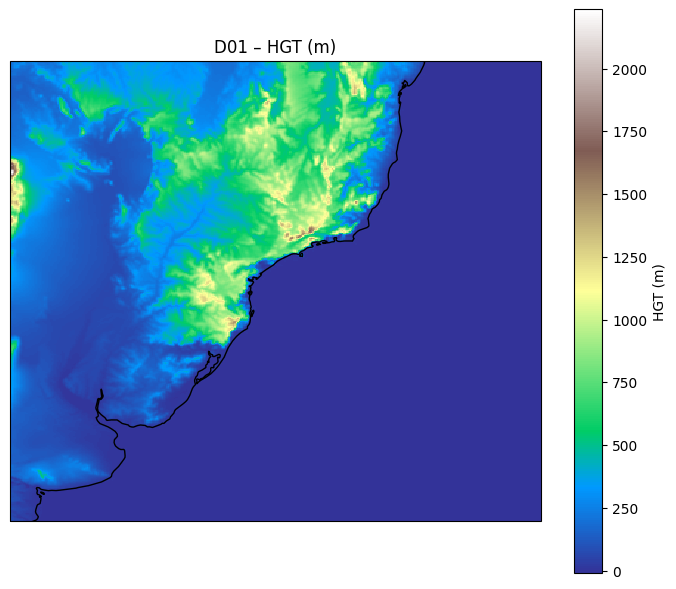

In [4]:
# positions and heights
lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]
hgt = data_20170206_D01["HGT"]

# plot
plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, hgt,
    cmap="terrain",
    shading="auto"
)

ax.coastlines()
ax.set_title("D01 – HGT (m)")

plt.colorbar(im, ax=ax, label="HGT (m)")
plt.tight_layout()
plt.show()

# close data file to save memory
data_20170206_D01.close()

#### Land Use Index

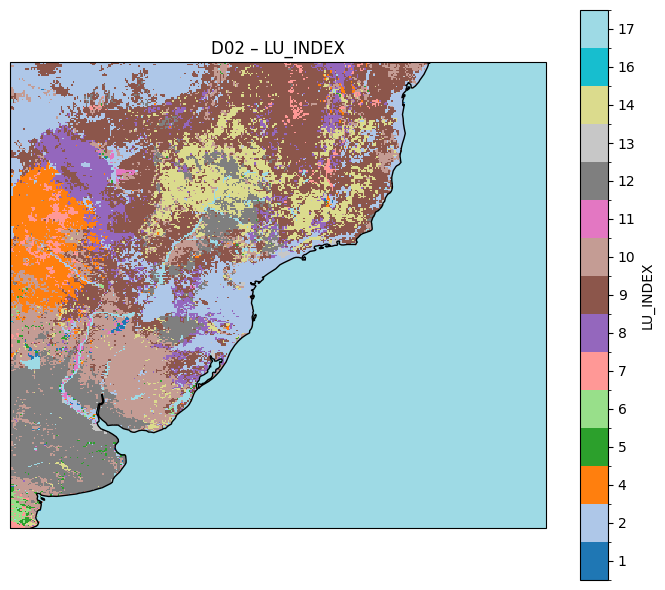

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]
lu  = data_20170206_D01["LU_INDEX"]

# drop optional Time dim (common in WRF)
if "Time" in lon.dims:
    lon = lon.isel(Time=0)
    lat = lat.isel(Time=0)

# --- unique categories that actually appear ---
lu_vals = np.unique(lu.values[~np.isnan(lu.values)]).astype(int)
lu_vals = np.sort(lu_vals)
K = len(lu_vals)

# --- remap LU_INDEX values for plotting ---
lu_int = lu.values.astype(int)
lu_mapped = np.searchsorted(lu_vals, lu_int)  # works because lu_vals is sorted

# --- discrete colormap/norm---
cmap = plt.get_cmap("tab20", K)
bounds = np.arange(-0.5, K + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon, lat, lu_mapped,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.coastlines()
ax.set_title("D02 – LU_INDEX")

# colorbar
cbar = plt.colorbar(im, ax=ax, ticks=np.arange(K), spacing="uniform")
cbar.ax.set_yticklabels(lu_vals.astype(int))
cbar.set_label("LU_INDEX")

plt.tight_layout()
plt.show()


### Calculating wind speed at 10 m height

In [6]:
# read wind components (all times)
u10 = data_20170206_D01["U10"]   # (Time, south_north, west_east)
v10 = data_20170206_D01["V10"]

# calculate wind speed for ALL times (m/s)
wspd = np.sqrt(u10**2 + v10**2)

#### plotting wind speed at 10 m height

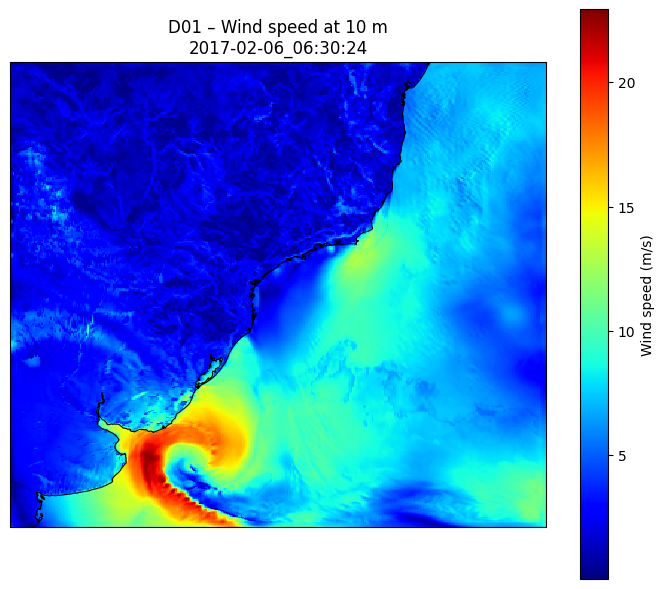

In [7]:
# select time index
tidx = 0  # change this to any Time index you want

ws_t = wspd.isel(Time=tidx)

lon = data_20170206_D01["XLONG"]
lat = data_20170206_D01["XLAT"]

# extract time string
time_str = (
    data_20170206_D01["Times"]
    .isel(Time=tidx)
    .values
)

# plot
plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon,
    lat,
    ws_t,
    cmap="jet",
    shading="auto"
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.set_title(f"D01 – Wind speed at 10 m\n{time_str}")

plt.colorbar(im, ax=ax, label="Wind speed (m/s)")
plt.tight_layout()
plt.show()

#### Ploting U wind component

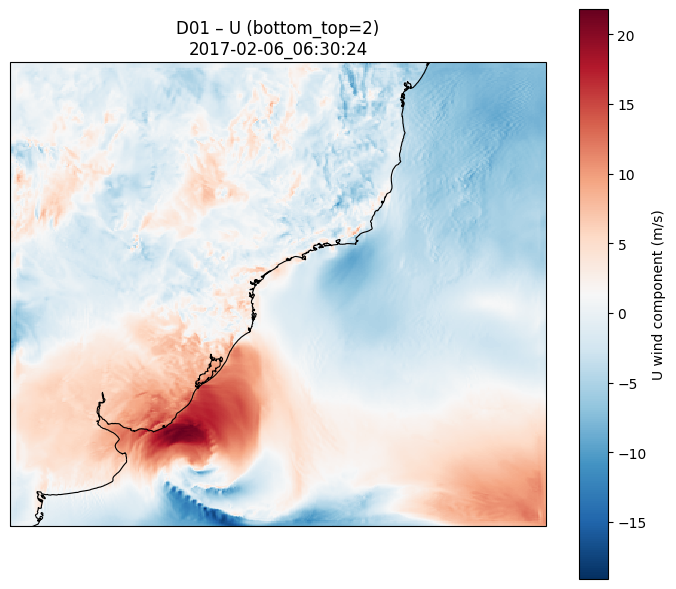

In [8]:
# --- select time and vertical level ---
time_index = 0
vertical_level = 2  # bottom_top index

# --- select U at fixed time/height (no unstaggering) ---
u = data_20170206_D01["U"].isel(Time=time_index, bottom_top=vertical_level)

# --- lon/lat on U grid ---
lon_u = data_20170206_D01["XLONG_U"]
lat_u = data_20170206_D01["XLAT_U"]

# --- extract time string ---
time_str = (
    data_20170206_D01["Times"]
    .isel(Time=time_index)
    .values
    .astype(str)
    .item()
)

# --- plot ---
fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_u, lat_u, u,
    cmap="RdBu_r",
    shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.set_title(f"D01 – U (bottom_top={vertical_level})\n{time_str}")

plt.colorbar(im, ax=ax, label="U wind component (m/s)")
plt.tight_layout()
plt.show()

### Exporting data to csv

In [9]:
data_20170206_D03 

<xarray.Dataset>
Dimensions:   (Time: 35, south_north: 354, west_east: 360, bottom_top: 4,
               bottom_top_stag: 5, west_east_stag: 361, south_north_stag: 355)
Coordinates:
    Times     (Time) |S19 ...
    XLAT      (south_north, west_east) float32 ...
    XLONG     (south_north, west_east) float32 ...
    XLAT_U    (south_north, west_east_stag) float32 ...
    XLONG_U   (south_north, west_east_stag) float32 ...
    XLAT_V    (south_north_stag, west_east) float32 ...
    XLONG_V   (south_north_stag, west_east) float32 ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, west_east_stag,
                                south_north_stag
Data variables: (12/21)
    T2        (Time, south_north, west_east) float32 ...
    TH2       (Time, south_north, west_east) float32 ...
    SST       (Time, south_north, west_east) float32 ...
    PSFC      (Time, south_north, west_east) float32 ...
    RAINC     (Time, south_north, west_east) float32 ...
    RAINNC    (Time, south_north, west_east) float32 ...
    ...        ...
    P         (Time, bottom_top, south_north, west_east) float32 ...
    PH        (Time, bottom_top_stag, south_north, west_east) float32 ...
    T         (Time, bottom_top, south_north, west_east) float32 ...
    U         (Time, bottom_top, south_north, west_east_stag) float32 ...
    V         (Time, bottom_top, south_north_stag, west_east) float32 ...
    W         (Time, bottom_top_stag, south_north, west_east) float32 ...
Attributes: (12/148)
    TITLE:                            OUTPUT FROM WRF V4.3.3 MODEL
    WEST-EAST_GRID_DIMENSION:        361
    SOUTH-NORTH_GRID_DIMENSION:      355
    BOTTOM-TOP_GRID_DIMENSION:       45
    DX:                              1000.0
    DY:                              1000.0
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

### Finding closest grid-point from input location

In [10]:
domains = {
    "D01": data_20170206_D01,
    "D02": data_20170206_D02,
    "D03": data_20170206_D03,
}

print("\n🌍 Latitude / Longitude ranges per WRF domain")
print("============================================")

for name, ds in domains.items():

    lat_da = ds["XLAT"]
    lon_da = ds["XLONG"]

    # drop optional Time dimension
    if "Time" in lat_da.dims:
        lat_da = lat_da.isel(Time=0)
        lon_da = lon_da.isel(Time=0)

    lat = lat_da.values
    lon = lon_da.values

    lat_min = float(np.nanmin(lat))
    lat_max = float(np.nanmax(lat))
    lon_min = float(np.nanmin(lon))
    lon_max = float(np.nanmax(lon))

    print(f"\n{name}")
    print("────────────────────────────────")
    print(f"Latitude : {lat_min:8.4f}°  to  {lat_max:8.4f}°")
    print(f"Longitude: {lon_min:8.4f}°  to  {lon_max:8.4f}°")



🌍 Latitude / Longitude ranges per WRF domain

D01
────────────────────────────────
Latitude : -40.9452°  to  -11.3874°
Longitude: -64.0216°  to  -29.9614°

D02
────────────────────────────────
Latitude : -31.9864°  to  -22.0606°
Longitude: -52.6682°  to  -41.3148°

D03
────────────────────────────────
Latitude : -28.7769°  to  -25.4656°
Longitude: -48.8837°  to  -45.0993°


In [11]:
# INPUT location (set these first)
lat0 = -27.50
lon0 = -48.30

In [12]:
ds = data_20170206_D03  #selecting D03 grid
out_csv = "example_u10_v10_timeseries.csv"

# 1) Get 2D lat/lon (mass grid) and drop optional Time dim
lat_da = ds["XLAT"]
lon_da = ds["XLONG"]

if "Time" in lat_da.dims:
    lat_da = lat_da.isel(Time=0)
    lon_da = lon_da.isel(Time=0)

lat2d = lat_da.values
lon2d = lon_da.values

# 2) Warn if outside grid bounding box (simple check)
lat_min = float(np.nanmin(lat2d))
lat_max = float(np.nanmax(lat2d))
lon_min = float(np.nanmin(lon2d))
lon_max = float(np.nanmax(lon2d))

outside = (lat0 < lat_min) or (lat0 > lat_max) or (lon0 < lon_min) or (lon0 > lon_max)
if outside:
    print(
        f"⚠️ Point ({lat0:.5f}, {lon0:.5f}) is outside grid bounding box:\n"
        f"    lat range: [{lat_min:.5f}, {lat_max:.5f}]\n"
        f"    lon range: [{lon_min:.5f}, {lon_max:.5f}]"
    )

# 3) Find closest grid point using haversine distance (km)
R = 6371.0  # km

lat_rad = np.deg2rad(lat2d)
lon_rad = np.deg2rad(lon2d)
lat0r = np.deg2rad(lat0)
lon0r = np.deg2rad(lon0)

dlat = lat_rad - lat0r
dlon = lon_rad - lon0r

a = np.sin(dlat / 2.0) ** 2 + np.cos(lat0r) * np.cos(lat_rad) * np.sin(dlon / 2.0) ** 2
c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
dist_km = R * c

flat_idx = int(np.nanargmin(dist_km))
j, i = np.unravel_index(flat_idx, dist_km.shape)
d_km = float(dist_km[j, i])

closest_lat = float(lat2d[j, i])
closest_lon = float(lon2d[j, i])

print("\n📍 Closest grid point (mass grid: XLAT/XLONG)")
print(f"Target lat/lon : ({lat0:.5f}, {lon0:.5f})")
print(f"Closest ij     : ({j}, {i})")
print(f"Closest lat/lon: ({closest_lat:.5f}, {closest_lon:.5f})")
print(f"Distance       : {d_km:.2f} km")

# 4) Extract U10/V10 for ALL times at that grid point
u10_ts = ds["U10"].isel(south_north=j, west_east=i).values
v10_ts = ds["V10"].isel(south_north=j, west_east=i).values

nT = ds.sizes["Time"]
time_strs = [
    ds["Times"].isel(Time=t).values.astype(str).item()
    for t in range(nT)
]

# 5) Save to CSV
df = pd.DataFrame(
    {
        "time_str": time_strs,
        "U10_mps": u10_ts.astype(float),
        "V10_mps": v10_ts.astype(float),
        "target_lat": lat0,
        "target_lon": lon0,
        "closest_lat": closest_lat,
        "closest_lon": closest_lon,
        "distance_km": d_km,
    }
)

df.to_csv(out_csv, index=False)
print(f"\n✅ Saved {len(df)} rows to: {out_csv}")


📍 Closest grid point (mass grid: XLAT/XLONG)
Target lat/lon : (-27.50000, -48.30000)
Closest ij     : (137, 55)
Closest lat/lon: (-27.50346, -48.30394)
Distance       : 0.55 km

✅ Saved 35 rows to: example_u10_v10_timeseries.csv


### Calculating height of the closes grid point above for different pressure vertical levels.

Height is calculated as $\frac{\text{PH} + \text{PHB}}{g}$, $g$ denotes the gravity acceleration.


In [13]:
data_20170206_D03['PH']

<xarray.DataArray 'PH' (Time: 35, bottom_top_stag: 5, south_north: 354,
                        west_east: 360)>
[22302000 values with dtype=float32]
Coordinates:
    Times    (Time) |S19 ...
    XLAT     (south_north, west_east) float32 -28.78 -28.78 ... -25.47 -25.47
    XLONG    (south_north, west_east) float32 -48.88 -48.87 ... -45.11 -45.1
Dimensions without coordinates: Time, bottom_top_stag, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  perturbation geopotential
    units:        m2 s-2
    stagger:      Z

In [14]:
data_20170206_D03['PHB']

<xarray.DataArray 'PHB' (bottom_top_stag: 5, south_north: 354, west_east: 360)>
[637200 values with dtype=float32]
Coordinates:
    XLAT     (south_north, west_east) float32 -28.78 -28.78 ... -25.47 -25.47
    XLONG    (south_north, west_east) float32 -48.88 -48.87 ... -45.11 -45.1
Dimensions without coordinates: bottom_top_stag, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  base-state geopotential
    units:        m2 s-2
    stagger:      Z

In [15]:
## showing height for closest grid point ab
fixed_location_and_time = (
    data_20170206_D03
    .sel(Time=0)
    .sel(south_north=j, west_east=i) # indices found from closes input location
)

In [16]:
g = 9.8  # gravitational acceleration (m s^-2)
vertical_level = 0

height_m = (
    fixed_location_and_time["PH"]
    .sel(bottom_top_stag=vertical_level)
    + fixed_location_and_time["PHB"]
    .sel(bottom_top_stag=vertical_level)
) / g

height_m.values

array(0.)

In [17]:
vertical_level = 3

height_m = (
    fixed_location_and_time["PH"]
    .sel(bottom_top_stag=vertical_level)
    + fixed_location_and_time["PHB"]
    .sel(bottom_top_stag=vertical_level)
) / g

height_m.values

array(104.62708765)

### WRF Air density

In [18]:
air_density_D01

<xarray.Dataset>
Dimensions:      (aggregation: 2, bottom_top: 5, south_north: 354,
                  west_east: 360)
Coordinates:
  * aggregation  (aggregation) object 'mean' 'std'
    XLONG        (south_north, west_east) float32 ...
    XLAT         (south_north, west_east) float32 ...
Dimensions without coordinates: bottom_top, south_north, west_east
Data variables:
    air_density  (aggregation, bottom_top, south_north, west_east) float32 ...

### Air density aggregations

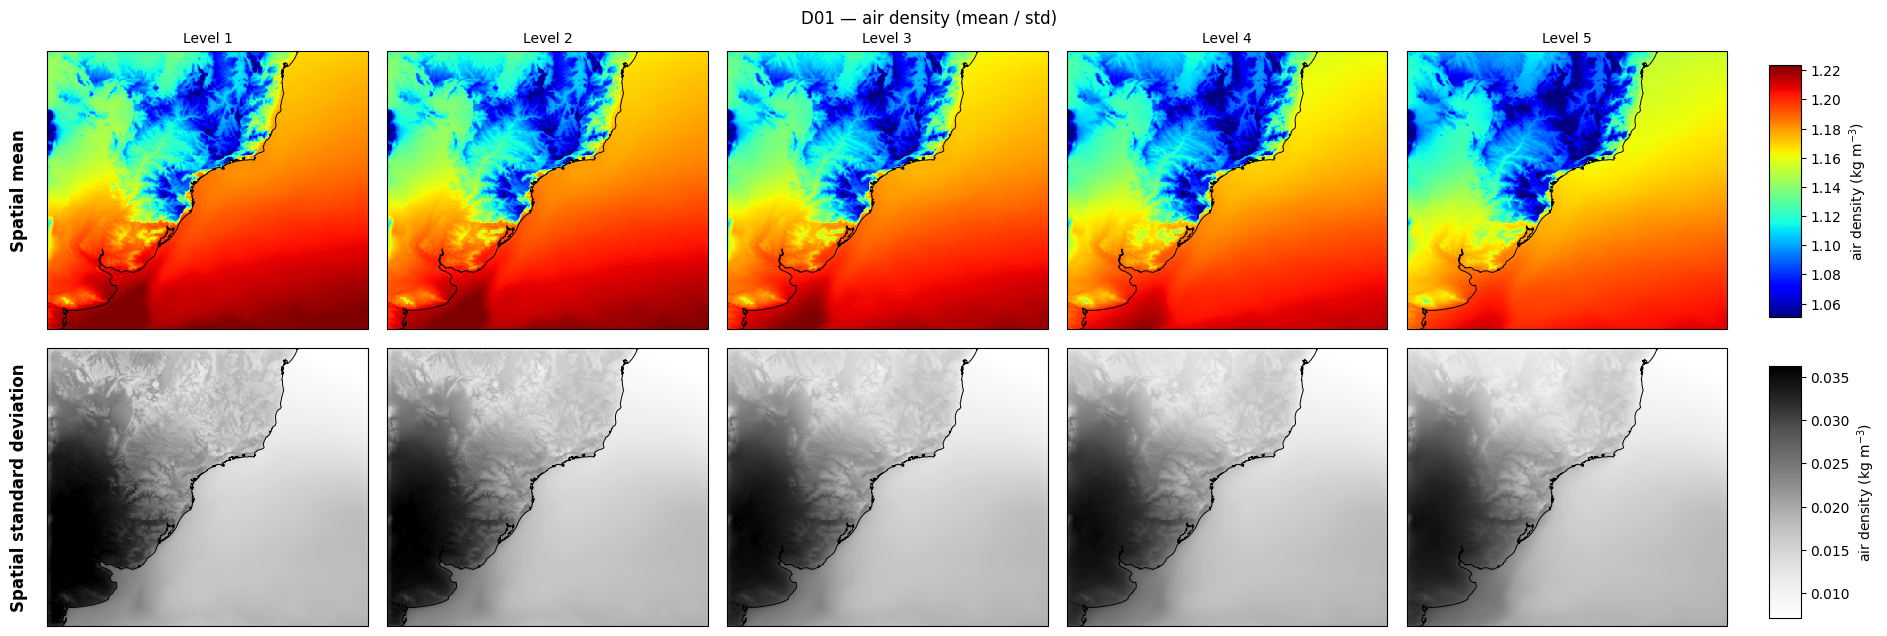

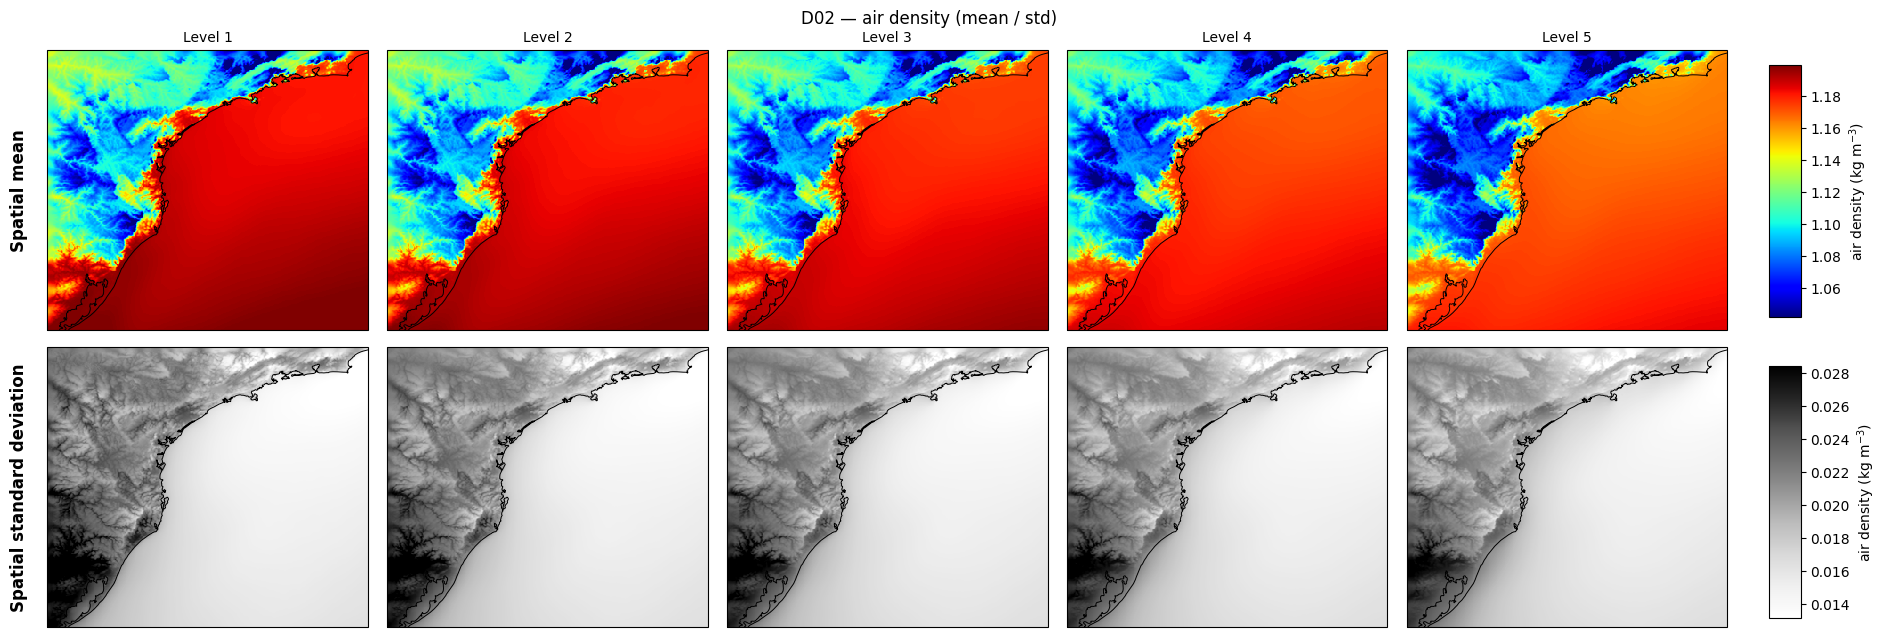

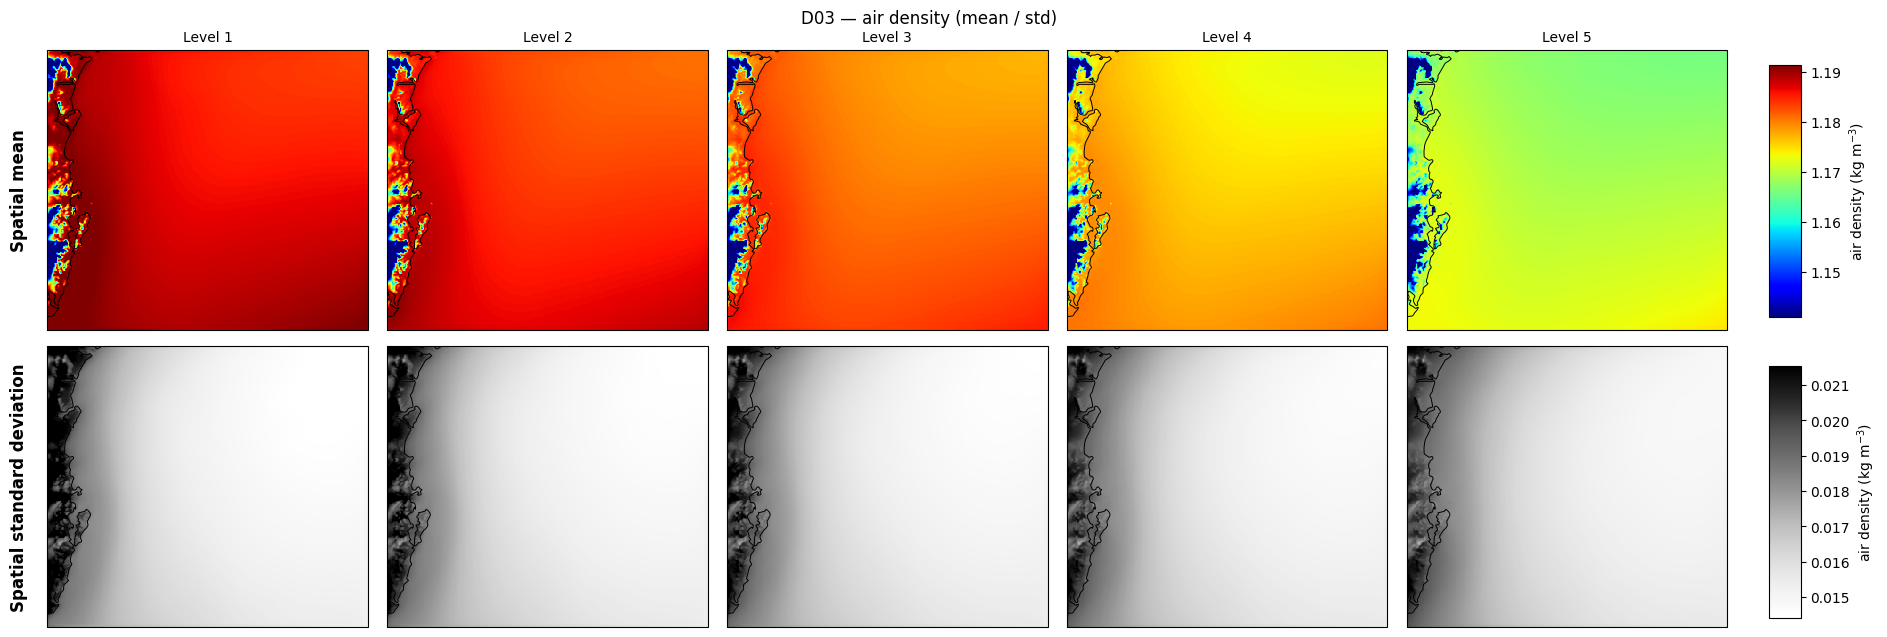

In [19]:
DATASETS = {
    "D01": air_density_D01,
    "D02": air_density_D02,
    "D03": air_density_D03,
}

CMAP_MEAN = "jet"
CMAP_STD = "Greys"

P_LO, P_HI = 1, 99
COAST_RES = "10m"
COAST_LW = 0.7

# plot for all domains
for domain, ds in DATASETS.items():

    rho = ds["air_density"]
    lat = ds["XLAT"]
    lon = ds["XLONG"]

    # safety: drop Time if present
    if "Time" in lat.dims:
        lat = lat.isel(Time=0, drop=True)
    if "Time" in lon.dims:
        lon = lon.isel(Time=0, drop=True)

    rho_mean = rho.sel(aggregation="mean")
    rho_std  = rho.sel(aggregation="std")

    n_levels = rho_mean.sizes["bottom_top"]

    mean_vals = rho_mean.values
    std_vals = rho_std.values

    vmin_mean, vmax_mean = np.nanpercentile(mean_vals, [P_LO, P_HI])
    vmin_std,  vmax_std  = np.nanpercentile(std_vals,  [P_LO, P_HI])

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        nrows=2,
        ncols=n_levels,
        figsize=(4.2 * n_levels, 7.0),
        subplot_kw={"projection": proj},
    )

    im_mean = None
    im_std = None

    for k in range(n_levels):
        # --- mean ---
        ax = axes[0, k]
        im_mean = ax.pcolormesh(
            lon, lat, rho_mean.isel(bottom_top=k),
            transform=proj, shading="auto",
            cmap=CMAP_MEAN, vmin=vmin_mean, vmax=vmax_mean,
        )
        ax.coastlines(resolution=COAST_RES, linewidth=COAST_LW)
        ax.set_title(f"Level {k+1}", fontsize=10)

        # --- std ---
        ax = axes[1, k]
        im_std = ax.pcolormesh(
            lon, lat, rho_std.isel(bottom_top=k),
            transform=proj, shading="auto",
            cmap=CMAP_STD, vmin=vmin_std, vmax=vmax_std,
        )
        ax.coastlines(resolution=COAST_RES, linewidth=COAST_LW)

    # layout
    fig.subplots_adjust(
        left=0.08, right=0.88, top=0.92, bottom=0.08,
        wspace=0.06, hspace=0.02,
    )

    # row labels
    axes[0, 0].text(
        -0.06, 0.5, "Spatial mean",
        transform=axes[0, 0].transAxes,
        rotation=90, va="center", ha="right",
        fontsize=12, fontweight="bold",
    )
    axes[1, 0].text(
        -0.06, 0.5, "Spatial standard deviation",
        transform=axes[1, 0].transAxes,
        rotation=90, va="center", ha="right",
        fontsize=12, fontweight="bold",
    )

    # colorbars
    cax_mean = fig.add_axes([0.90, 0.53, 0.015, 0.36])
    cb_mean = fig.colorbar(im_mean, cax=cax_mean)
    cb_mean.set_label("air density (kg m$^{-3}$)")

    cax_std = fig.add_axes([0.90, 0.10, 0.015, 0.36])
    cb_std = fig.colorbar(im_std, cax=cax_std)
    cb_std.set_label("air density (kg m$^{-3}$)")

    fig.suptitle(f"{domain} — air density (mean / std)", y=0.97)
    plt.show()


## SAR data

In [20]:
SAR_1000m

<xarray.Dataset>
Dimensions:   (Time: 104, south_north: 82, west_east: 57, satellite: 104)
Coordinates:
    XLAT      (south_north, west_east) float32 ...
    XLONG     (south_north, west_east) float32 ...
    Times     (Time) |S19 ...
    XSAT      (satellite) object ...
Dimensions without coordinates: Time, south_north, west_east, satellite
Data variables:
    U10       (Time, south_north, west_east) float32 ...
    V10       (Time, south_north, west_east) float32 ...
    WIND_SPD  (Time, south_north, west_east) float32 ...
    WIND_DIR  (Time, south_north, west_east) float32 ...

### Spatial average per acquisition

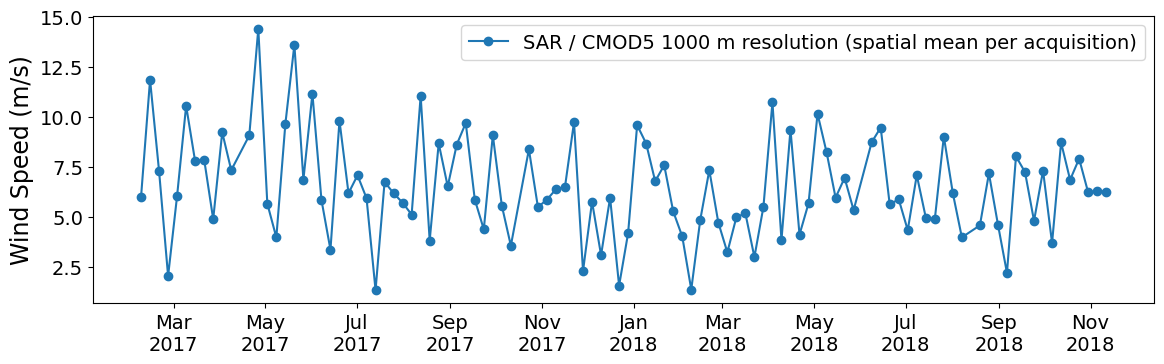

In [21]:
# convert time to datetime
time = pd.to_datetime(
    [x.decode("utf-8") for x in SAR_1000m["Times"].values],
    format="%Y-%m-%d_%H:%M:%S",
    errors="raise",
)

# spatial mean over lat/lon
wspd_mean = SAR_1000m["WIND_SPD"].mean(dim=("south_north", "west_east"))

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, wspd_mean, "o-", label="SAR / CMOD5 1000 m resolution (spatial mean per acquisition)")

# --- x-axis formatting: MMM \n YYYY ---
def fmt_date(x, pos=None):
    return mdates.num2date(x).strftime("%b\n%Y").title()

# styling
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_date))
ax.tick_params(axis="both", which="major", labelsize=14)
ax.set_ylabel("Wind Speed (m/s)", fontsize=17)
ax.legend(fontsize=14, loc="upper right")
plt.tight_layout(pad=2.0)

plt.show()
